# MỨC 2 — MACHINE LEARNING REGRESSION

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset.zip to Dataset.zip


In [ ]:
import zipfile
import os
import glob

zip_path = "/content/Dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

csv_files = glob.glob(extract_path + "/**/*.csv", recursive=True)

print("Các file CSV tìm thấy:")
for f in csv_files:
    print(f)

Các file CSV tìm thấy:
/content/dataset/Dataset/Dataset/products.csv
/content/dataset/Dataset/Dataset/cities.csv
/content/dataset/Dataset/Dataset/customers.csv
/content/dataset/Dataset/Dataset/categories.csv
/content/dataset/Dataset/Dataset/countries.csv
/content/dataset/Dataset/Dataset/sales.csv
/content/dataset/Dataset/Dataset/employees.csv


In [ ]:
import pandas as pd
import numpy as np
import os

base_path = "/content/dataset/Dataset/Dataset"

sales = pd.read_csv(os.path.join(base_path, "sales.csv"))
products = pd.read_csv(os.path.join(base_path, "products.csv"))
categories = pd.read_csv(os.path.join(base_path, "categories.csv"))
customers = pd.read_csv(os.path.join(base_path, "customers.csv"))
cities = pd.read_csv(os.path.join(base_path, "cities.csv"))
countries = pd.read_csv(os.path.join(base_path, "countries.csv"))
employees = pd.read_csv(os.path.join(base_path, "employees.csv"))

print("Sales:", sales.shape)
print("Products:", products.shape)
print("Categories:", categories.shape)
print("Customers:", customers.shape)
print("Cities:", cities.shape)
print("Countries:", countries.shape)
print("Employees:", employees.shape)

sales.head()

Sales: (6758125, 9)
Products: (452, 9)
Categories: (11, 2)
Customers: (98759, 6)
Cities: (96, 4)
Countries: (206, 3)
Employees: (23, 8)


,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber
0,1,6,27039,381,7,0.0,0.0,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G
1,2,16,25011,61,7,0.0,0.0,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8
2,3,13,94024,23,24,0.0,0.0,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0
3,4,8,73966,176,19,0.2,0.0,2018-04-07 14:43:55.420,R3DR9MLD5NR76VO17ULE
4,5,10,32653,310,9,0.0,0.0,2018-02-12 15:37:03.940,4BGS0Z5OMAZ8NDAFHHP3


In [ ]:
# Đổi SalesDate sang kiểu ngày
sales["SalesDate"] = pd.to_datetime(sales["SalesDate"], errors="coerce")

# Bỏ dòng thiếu ngày bán
sales = sales.dropna(subset=["SalesDate"])

# Nối sales với products để lấy Price và CategoryID
df = sales.merge(
    products[["ProductID", "Price", "CategoryID"]],
    on="ProductID",
    how="left"
)

# Nối categories để lấy CategoryName
df = df.merge(
    categories[["CategoryID", "CategoryName"]],
    on="CategoryID",
    how="left"
)

# Nối customers để lấy CityID
df = df.merge(
    customers[["CustomerID", "CityID"]],
    on="CustomerID",
    how="left"
)

# Nối cities để lấy CountryID
df = df.merge(
    cities[["CityID", "CountryID"]],
    on="CityID",
    how="left"
)

# Nối countries để lấy CountryName
df = df.merge(
    countries[["CountryID", "CountryName"]],
    on="CountryID",
    how="left"
)

# Tính lại doanh thu vì TotalPrice trong file gốc toàn 0
df["Revenue"] = df["Quantity"] * df["Price"] * (1 - df["Discount"])

# Tạo biến thời gian
df["Year"] = df["SalesDate"].dt.year
df["Month"] = df["SalesDate"].dt.month
df["YearMonth"] = df["SalesDate"].dt.to_period("M").dt.to_timestamp()

print(df.shape)
df.head()

(6690599, 19)


,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Price,CategoryID,CategoryName,CityID,CountryID,CountryName,Revenue,Year,Month,YearMonth
0,1,6,27039,381,7,0.0,0.0,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G,44.2337,1,Confections,54,32,United States,309.63590,2018,2,2018-02-01
1,2,16,25011,61,7,0.0,0.0,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8,62.5460,8,Grain,71,32,United States,437.82200,2018,2,2018-02-01
2,3,13,94024,23,24,0.0,0.0,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0,79.0184,11,Produce,2,32,United States,1896.44160,2018,5,2018-05-01
3,4,8,73966,176,19,0.2,0.0,2018-04-07 14:43:55.420,R3DR9MLD5NR76VO17ULE,81.3167,6,Seafood,45,32,United States,1236.01384,2018,4,2018-04-01
4,5,10,32653,310,9,0.0,0.0,2018-02-12 15:37:03.940,4BGS0Z5OMAZ8NDAFHHP3,79.9780,9,Poultry,82,32,United States,719.80200,2018,2,2018-02-01


In [ ]:
group_cols = [
    "SalesPersonID",
    "YearMonth",
    "Year",
    "Month",
    "CategoryName",
    "CountryName"
]

ml_df = df.groupby(group_cols).agg(
    TotalSalesRevenue=("Revenue", "sum"),
    NumberOfOrders=("TransactionNumber", "nunique"),
    AvgDiscount=("Discount", "mean"),
    TotalQuantity=("Quantity", "sum")
).reset_index()

# Average Basket Size = số lượng trung bình trên mỗi đơn
ml_df["AverageBasketSize"] = ml_df["TotalQuantity"] / ml_df["NumberOfOrders"]

# Historical Sales Trend = doanh thu kỳ trước của cùng nhân viên, ngành hàng, quốc gia
ml_df = ml_df.sort_values(
    ["SalesPersonID", "CategoryName", "CountryName", "YearMonth"]
)

ml_df["HistoricalSalesTrend"] = ml_df.groupby(
    ["SalesPersonID", "CategoryName", "CountryName"]
)["TotalSalesRevenue"].shift(1)

# Tháng đầu chưa có doanh thu trước đó thì cho bằng 0
ml_df["HistoricalSalesTrend"] = ml_df["HistoricalSalesTrend"].fillna(0)

# Xóa dòng lỗi nếu có
ml_df = ml_df.dropna()

print(ml_df.shape)
ml_df.head()

(1265, 12)


,SalesPersonID,YearMonth,Year,Month,CategoryName,CountryName,TotalSalesRevenue,NumberOfOrders,AvgDiscount,TotalQuantity,AverageBasketSize,HistoricalSalesTrend
0,1,2018-01-01,2018,1,Beverages,United States,3.692110e+06,5757,0.030745,75877,13.179955,0.000000e+00
11,1,2018-02-01,2018,2,Beverages,United States,3.476603e+06,5366,0.029668,71054,13.241521,3.692110e+06
22,1,2018-03-01,2018,3,Beverages,United States,3.838078e+06,5785,0.030717,76609,13.242697,3.476603e+06
33,1,2018-04-01,2018,4,Beverages,United States,3.608720e+06,5572,0.029864,73163,13.130474,3.838078e+06
44,1,2018-05-01,2018,5,Beverages,United States,1.196122e+06,1774,0.027678,23195,13.074972,3.608720e+06


In [ ]:
from sklearn.model_selection import train_test_split

# Biến mục tiêu cần dự đoán
target = "TotalSalesRevenue"

# Các đặc trưng đầu vào
features = [
    "SalesPersonID",
    "Year",
    "Month",
    "CategoryName",
    "CountryName",
    "NumberOfOrders",
    "AvgDiscount",
    "AverageBasketSize",
    "HistoricalSalesTrend"
]

X = ml_df[features].copy()
y = ml_df[target].copy()

# Chuyển SalesPersonID sang dạng phân loại
X["SalesPersonID"] = X["SalesPersonID"].astype(str)

# Cột phân loại
categorical_features = [
    "SalesPersonID",
    "CategoryName",
    "CountryName"
]

# Cột số
numeric_features = [
    "Year",
    "Month",
    "NumberOfOrders",
    "AvgDiscount",
    "AverageBasketSize",
    "HistoricalSalesTrend"
]

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1012, 9)
Test: (253, 9)


In [ ]:
# Cài XGBoost nếu Colab chưa có
!pip -q install xgboost

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Tiền xử lý:
# - Cột số: chuẩn hóa bằng StandardScaler
# - Cột phân loại: mã hóa OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Khai báo 3 mô hình theo yêu cầu đề
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost Regressor": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        objective="reg:squarederror"
    )
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Huấn luyện mô hình
    pipeline.fit(X_train, y_train)

    # Dự đoán trên tập test
    y_pred = pipeline.predict(X_test)

    # Tính metric đánh giá
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

# Làm tròn kết quả cho dễ nhìn
results_df["MAE"] = results_df["MAE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)
results_df["R2 Score"] = results_df["R2 Score"].round(4)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,61355.15,84114.67,0.9954
1,Random Forest Regressor,45032.76,57652.15,0.9979
2,XGBoost Regressor,42303.81,54081.96,0.9981


Kết quả cho thấy cả ba mô hình hồi quy đều có khả năng dự đoán doanh thu bán hàng khá tốt, thể hiện qua R² Score đều lớn hơn 0.99. Trong đó, XGBoost Regressor đạt kết quả tốt nhất với MAE = 42,303.81, RMSE = 54,081.96 và R² Score = 0.9981. Điều này cho thấy mô hình XGBoost có sai số dự đoán thấp nhất và giải thích được phần lớn sự biến động của doanh thu bán hàng.

Random Forest Regressor cũng cho kết quả tốt với MAE = 45,032.76, RMSE = 57,652.15 và R² Score = 0.9979, tuy nhiên vẫn thấp hơn một chút so với XGBoost. Linear Regression có kết quả thấp nhất trong ba mô hình, do mô hình tuyến tính chưa thể biểu diễn tốt các mối quan hệ phức tạp giữa số đơn hàng, tỷ lệ chiết khấu, ngành hàng, quốc gia, kích thước giỏ hàng trung bình và xu hướng doanh thu trong quá khứ.

Từ kết quả trên, XGBoost Regressor được lựa chọn là mô hình phù hợp nhất để dự đoán sales performance trong bài toán này.

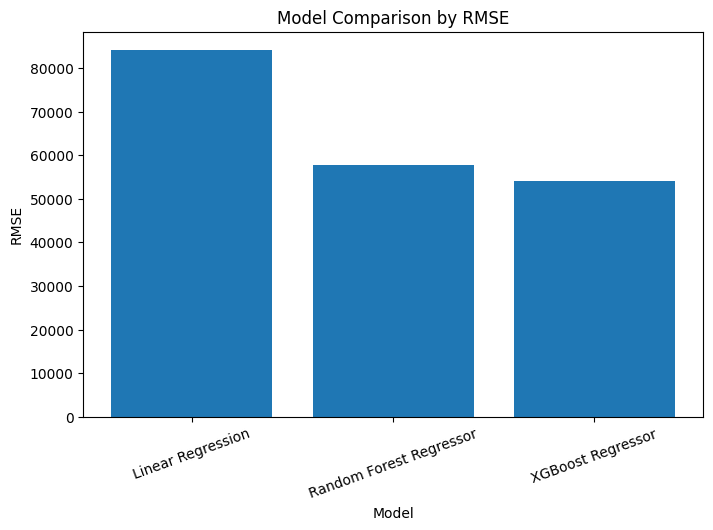

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

Biểu đồ so sánh RMSE cho thấy XGBoost Regressor có sai số thấp nhất trong ba mô hình, tiếp theo là Random Forest Regressor và Linear Regression. Vì RMSE càng thấp thì mô hình dự đoán càng chính xác, XGBoost Regressor được xem là mô hình phù hợp nhất để dự đoán doanh thu bán hàng trong bài toán này. Kết quả này cũng phù hợp với bảng đánh giá trước đó khi XGBoost có MAE thấp nhất, RMSE thấp nhất và R² Score cao nhất.

# MỨC 3 — PERFORMANCE ANALYTICS & FORECASTING

In [9]:
# MỨC 3 - DỰ BÁO DOANH THU BẰNG ARIMA

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Gom doanh thu theo ngày
daily_sales = df.copy()
daily_sales["SalesDateOnly"] = daily_sales["SalesDate"].dt.date

daily_sales = daily_sales.groupby("SalesDateOnly").agg(
    DailyRevenue=("Revenue", "sum")
).reset_index()

daily_sales["SalesDateOnly"] = pd.to_datetime(daily_sales["SalesDateOnly"])

# Đưa ngày thành index và đảm bảo dữ liệu theo tần suất ngày
daily_sales = daily_sales.set_index("SalesDateOnly").sort_index()
daily_sales = daily_sales.asfreq("D")

# Nếu có ngày không phát sinh bán hàng thì cho doanh thu = 0
daily_sales["DailyRevenue"] = daily_sales["DailyRevenue"].fillna(0)

print(daily_sales.shape)
daily_sales.head()

(129, 1)


,DailyRevenue
SalesDateOnly,
2018-01-01,3.340367e+07
2018-01-02,3.318592e+07
2018-01-03,3.311388e+07
2018-01-04,3.298996e+07
2018-01-05,3.330512e+07


In [11]:
# TÌM MÔ HÌNH ARIMA TỐT HƠN BẰNG CÁCH THỬ NHIỀU THAM SỐ

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Chia train/test: 14 ngày cuối làm test
train = daily_sales["DailyRevenue"][:-14]
test = daily_sales["DailyRevenue"][-14:]

# Dùng log để giảm dao động doanh thu lớn
train_log = np.log1p(train)

orders = [
    (1, 0, 1), (2, 0, 1), (3, 0, 1),
    (1, 1, 1), (2, 1, 1), (3, 1, 1),
    (1, 1, 2), (2, 1, 2), (3, 1, 2),
    (5, 1, 1), (7, 1, 1)
]

best_result = None
all_arima_results = []

for order in orders:
    try:
        model = ARIMA(train_log, order=order)
        result = model.fit()

        forecast_log = result.forecast(steps=len(test))
        forecast = np.expm1(forecast_log)

        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        r2 = r2_score(test, forecast)

        all_arima_results.append({
            "Order": order,
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        })

        if best_result is None or rmse < best_result["RMSE"]:
            best_result = {
                "Order": order,
                "MAE": mae,
                "RMSE": rmse,
                "R2 Score": r2,
                "Forecast": forecast
            }

    except:
        pass

arima_search_df = pd.DataFrame(all_arima_results)
arima_search_df = arima_search_df.sort_values("RMSE")

arima_search_df.head()

,Order,MAE,RMSE,R2 Score
10,"(7, 1, 1)",165467.791682,207121.247952,-0.108267
9,"(5, 1, 1)",168485.298821,213619.224482,-0.178897
2,"(3, 0, 1)",169754.218264,217794.124690,-0.225427
4,"(2, 1, 1)",173448.411843,221728.712164,-0.270103
1,"(2, 0, 1)",173949.324634,222047.495345,-0.273758


In [12]:
best_arima_result_df = pd.DataFrame({
    "Model": ["Best ARIMA"],
    "Order": [best_result["Order"]],
    "MAE": [round(best_result["MAE"], 2)],
    "RMSE": [round(best_result["RMSE"], 2)],
    "R2 Score": [round(best_result["R2 Score"], 4)]
})

forecast_test = best_result["Forecast"]

best_arima_result_df

,Model,Order,MAE,RMSE,R2 Score
0,Best ARIMA,"(7, 1, 1)",165467.79,207121.25,-0.1083


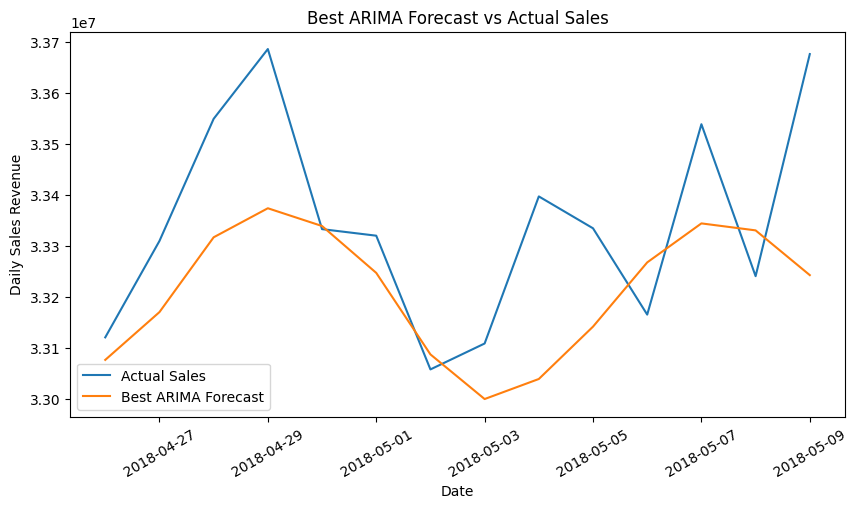

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(test.index, test, label="Actual Sales")
plt.plot(test.index, forecast_test, label="Best ARIMA Forecast")

plt.title("Best ARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Daily Sales Revenue")
plt.legend()
plt.xticks(rotation=30)
plt.show()

In [14]:
# Dự báo doanh thu 30 ngày tiếp theo bằng Best ARIMA

best_order = best_result["Order"]

# Huấn luyện lại trên toàn bộ dữ liệu
final_arima_model = ARIMA(
    np.log1p(daily_sales["DailyRevenue"]),
    order=best_order
)

final_arima_result = final_arima_model.fit()

# Dự báo 30 ngày
future_steps = 30
future_forecast_log = final_arima_result.forecast(steps=future_steps)
future_forecast = np.expm1(future_forecast_log)

future_dates = pd.date_range(
    start=daily_sales.index.max() + pd.Timedelta(days=1),
    periods=future_steps,
    freq="D"
)

future_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "ForecastRevenue": future_forecast.values
})

future_forecast_df.head()

,Date,ForecastRevenue
0,2018-05-10,3.337048e+07
1,2018-05-11,3.324492e+07
2,2018-05-12,3.326384e+07
3,2018-05-13,3.322732e+07
4,2018-05-14,3.328506e+07


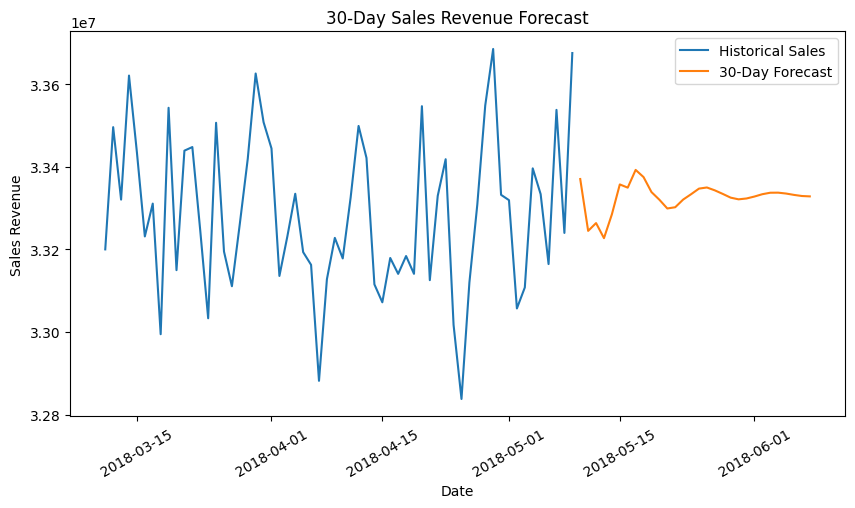

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_sales.index[-60:],
    daily_sales["DailyRevenue"][-60:],
    label="Historical Sales"
)

plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["ForecastRevenue"],
    label="30-Day Forecast"
)

plt.title("30-Day Sales Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Sales Revenue")
plt.legend()
plt.xticks(rotation=30)
plt.show()

In [18]:
# MỨC 3 - PERFORMANCE ANALYTICS: PHÂN TÍCH NHÂN VIÊN SUY GIẢM / ỔN ĐỊNH

import numpy as np
import pandas as pd

# 1. Loại tháng chưa đầy đủ dữ liệu
# Lý do: tháng 2018-05 chỉ có vài ngày nên doanh thu thấp bất thường,
# nếu dùng tháng này sẽ làm tất cả nhân viên bị hiểu nhầm là suy giảm.

df["SalesDateOnly"] = df["SalesDate"].dt.date

month_days = df.groupby("YearMonth").agg(
    DaysWithSales=("SalesDateOnly", "nunique")
).reset_index()

complete_months = month_days[
    month_days["DaysWithSales"] >= 25
]["YearMonth"]

# 2. Gom doanh thu theo nhân viên và tháng đầy đủ
employee_monthly = ml_df[
    ml_df["YearMonth"].isin(complete_months)
].groupby(
    ["SalesPersonID", "YearMonth"]
).agg(
    MonthlyRevenue=("TotalSalesRevenue", "sum"),
    MonthlyOrders=("NumberOfOrders", "sum")
).reset_index()

employee_monthly = employee_monthly.sort_values(["SalesPersonID", "YearMonth"])

# 3. Tính tăng trưởng doanh thu theo tháng
employee_monthly["PreviousMonthRevenue"] = employee_monthly.groupby(
    "SalesPersonID"
)["MonthlyRevenue"].shift(1)

employee_monthly["MonthlyGrowthRate"] = (
    (employee_monthly["MonthlyRevenue"] - employee_monthly["PreviousMonthRevenue"])
    / employee_monthly["PreviousMonthRevenue"]
)

# 4. Hàm tính xu hướng doanh thu
def calculate_trend_slope(group):
    group = group.sort_values("YearMonth")
    y = group["MonthlyRevenue"].values
    x = np.arange(len(y))

    if len(y) < 2:
        return 0

    return np.polyfit(x, y, 1)[0]

# 5. Tính độ ổn định doanh thu
employee_stability = employee_monthly.groupby("SalesPersonID").agg(
    AvgMonthlyRevenue=("MonthlyRevenue", "mean"),
    StdMonthlyRevenue=("MonthlyRevenue", "std"),
    AvgMonthlyOrders=("MonthlyOrders", "mean"),
    AvgGrowthRate=("MonthlyGrowthRate", "mean")
).reset_index()

employee_stability["StabilityCV"] = (
    employee_stability["StdMonthlyRevenue"] / employee_stability["AvgMonthlyRevenue"]
)

# 6. Tính xu hướng doanh thu
trend_slope = employee_monthly.groupby("SalesPersonID").apply(
    calculate_trend_slope
).reset_index(name="TrendSlope")

# 7. Lấy tháng gần nhất nhưng chỉ trong các tháng đầy đủ
latest_month = employee_monthly.sort_values("YearMonth").groupby(
    "SalesPersonID"
).tail(1)

latest_month = latest_month[[
    "SalesPersonID",
    "YearMonth",
    "MonthlyRevenue",
    "PreviousMonthRevenue",
    "MonthlyGrowthRate"
]]

# 8. Ghép bảng phân tích hiệu suất
performance_analytics = employee_stability.merge(
    trend_slope,
    on="SalesPersonID",
    how="left"
).merge(
    latest_month,
    on="SalesPersonID",
    how="left"
)

# 9. Phân loại trạng thái hiệu suất
def classify_performance(row):
    if row["TrendSlope"] < 0 and row["MonthlyGrowthRate"] < -0.05:
        return "Declining Performance"
    elif row["StabilityCV"] < 0.10:
        return "Stable Performance"
    elif row["TrendSlope"] > 0:
        return "Improving Performance"
    else:
        return "Fluctuating Performance"

performance_analytics["PerformanceStatus"] = performance_analytics.apply(
    classify_performance,
    axis=1
)

performance_analytics = performance_analytics.sort_values(
    ["PerformanceStatus", "MonthlyGrowthRate"]
)

print("Các tháng được dùng để phân tích:")
display(month_days)

print("Kết quả phân loại hiệu suất nhân viên:")
display(performance_analytics.head(10))

Các tháng được dùng để phân tích:


,YearMonth,DaysWithSales
0,2018-01-01,31
1,2018-02-01,28
2,2018-03-01,31
3,2018-04-01,30
4,2018-05-01,9


Kết quả phân loại hiệu suất nhân viên:


,SalesPersonID,AvgMonthlyRevenue,StdMonthlyRevenue,AvgMonthlyOrders,AvgGrowthRate,StabilityCV,TrendSlope,YearMonth,MonthlyRevenue,PreviousMonthRevenue,MonthlyGrowthRate,PerformanceStatus
8,9,4.325478e+07,2.248866e+06,67719.25,-0.011286,0.051991,-146149.283368,2018-04-01,4.283581e+07,4.502560e+07,-0.048634,Stable Performance
0,1,4.316022e+07,2.044936e+06,67466.00,-0.007619,0.047380,8426.643317,2018-04-01,4.290905e+07,4.494872e+07,-0.045378,Stable Performance
16,17,4.291809e+07,1.977253e+06,67374.00,-0.007145,0.046070,24723.600747,2018-04-01,4.269505e+07,4.466173e+07,-0.044035,Stable Performance
14,15,4.325814e+07,2.272178e+06,67713.75,-0.007227,0.052526,31023.901697,2018-04-01,4.314992e+07,4.508227e+07,-0.042863,Stable Performance
11,12,4.345176e+07,2.097893e+06,67538.50,-0.008853,0.048281,-51301.744825,2018-04-01,4.321173e+07,4.512125e+07,-0.042320,Stable Performance
4,5,4.355123e+07,2.316857e+06,67613.75,-0.007095,0.053198,33535.865659,2018-04-01,4.350661e+07,4.533101e+07,-0.040246,Stable Performance
21,22,4.345674e+07,2.087246e+06,67488.75,-0.011848,0.048030,-196795.361575,2018-04-01,4.312104e+07,4.487697e+07,-0.039128,Stable Performance
3,4,4.352015e+07,2.120244e+06,67841.50,-0.006007,0.048719,67674.866205,2018-04-01,4.355821e+07,4.513580e+07,-0.034952,Stable Performance
19,20,4.360465e+07,2.070868e+06,67584.25,-0.010688,0.047492,-152370.806761,2018-04-01,4.339268e+07,4.496399e+07,-0.034946,Stable Performance
12,13,4.357617e+07,2.199206e+06,67605.00,-0.007297,0.050468,10344.383881,2018-04-01,4.358408e+07,4.514653e+07,-0.034608,Stable Performance


In [19]:
status_count = performance_analytics["PerformanceStatus"].value_counts().reset_index()
status_count.columns = ["PerformanceStatus", "NumberOfEmployees"]

status_count

,PerformanceStatus,NumberOfEmployees
0,Stable Performance,23


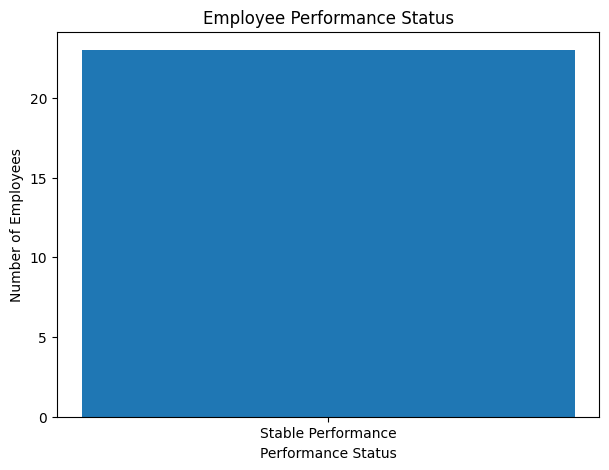

In [20]:
plt.figure(figsize=(7, 5))

plt.bar(
    status_count["PerformanceStatus"],
    status_count["NumberOfEmployees"]
)

plt.title("Employee Performance Status")
plt.xlabel("Performance Status")
plt.ylabel("Number of Employees")
plt.show()

In [21]:
# TOP NHÂN VIÊN CÓ DOANH THU ỔN ĐỊNH NHẤT VÀ BIẾN ĐỘNG NHẤT

stability_ranking = performance_analytics[[
    "SalesPersonID",
    "AvgMonthlyRevenue",
    "StabilityCV",
    "TrendSlope",
    "AvgGrowthRate",
    "PerformanceStatus"
]].copy()

# StabilityCV càng thấp thì doanh thu càng ổn định
stability_ranking = stability_ranking.sort_values("StabilityCV")

print("Top 5 nhân viên có doanh thu ổn định nhất:")
display(stability_ranking.head(5))

print("Top 5 nhân viên có doanh thu biến động mạnh nhất:")
display(stability_ranking.tail(5))

Top 5 nhân viên có doanh thu ổn định nhất:


,SalesPersonID,AvgMonthlyRevenue,StabilityCV,TrendSlope,AvgGrowthRate,PerformanceStatus
22,23,4.326607e+07,0.041764,73018.766133,-0.004905,Stable Performance
18,19,4.337138e+07,0.044070,92650.078298,-0.005111,Stable Performance
9,10,4.311903e+07,0.044646,-83671.820969,-0.008784,Stable Performance
16,17,4.291809e+07,0.046070,24723.600747,-0.007145,Stable Performance
6,7,4.347108e+07,0.046164,83780.368635,-0.005465,Stable Performance


Top 5 nhân viên có doanh thu biến động mạnh nhất:


,SalesPersonID,AvgMonthlyRevenue,StabilityCV,TrendSlope,AvgGrowthRate,PerformanceStatus
7,8,4.352169e+07,0.051844,42319.691361,-0.006488,Stable Performance
8,9,4.325478e+07,0.051991,-146149.283368,-0.011286,Stable Performance
14,15,4.325814e+07,0.052526,31023.901697,-0.007227,Stable Performance
4,5,4.355123e+07,0.053198,33535.865659,-0.007095,Stable Performance
20,21,4.373418e+07,0.055691,128402.300787,-0.004428,Stable Performance


Kết quả phân tích độ ổn định doanh thu cho thấy toàn bộ 23 nhân viên đều thuộc nhóm Stable Performance sau khi loại bỏ tháng 2018-05 do tháng này chưa đầy đủ dữ liệu. Điều này cho thấy doanh thu của nhân viên tương đối ổn định trong các tháng đầy đủ từ tháng 01 đến tháng 04 năm 2018.

Chỉ số StabilityCV được sử dụng để đánh giá mức độ biến động doanh thu theo tháng. StabilityCV càng thấp thì doanh thu của nhân viên càng ổn định. Trong đó, các nhân viên có doanh thu ổn định nhất là SalesPersonID 23, 19, 10, 17 và 7. Ngược lại, các nhân viên có mức biến động doanh thu cao hơn là SalesPersonID 8, 9, 15, 5 và 21. Tuy nhiên, mức biến động này vẫn chưa đủ lớn để xếp vào nhóm suy giảm hiệu suất.

Kết quả này giúp doanh nghiệp đánh giá được tính ổn định trong hiệu suất bán hàng của từng nhân viên, đồng thời hỗ trợ xây dựng KPI phù hợp hơn dựa trên doanh thu trung bình, xu hướng tăng trưởng và mức độ biến động doanh số theo thời gian.